In [14]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from pathlib import Path
from cmdstanpy import CmdStanModel

blog_visuals = Path("visuals")
blog_visuals.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"axes.titlesize": 14, "axes.labelsize": 13,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 12,})

Negative binomial fit parameters: r = 11.9284, p = 0.4901
Mean non-penalty shots per team per match: 12.4096
Variance non-penalty shots per team per match: 25.3198


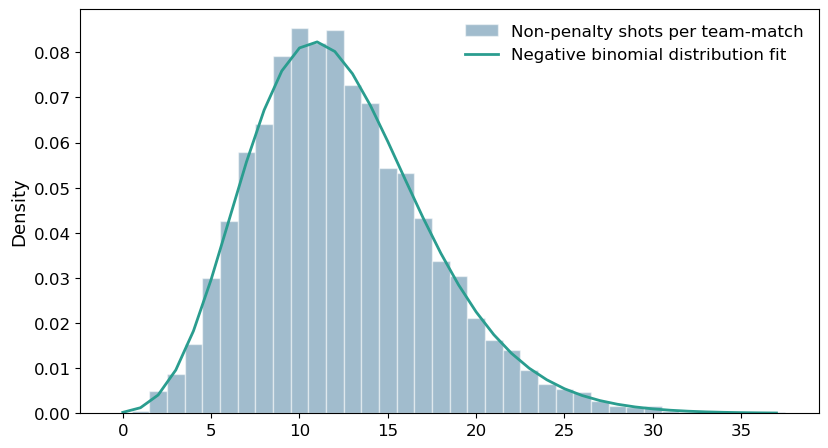

In [41]:
shots = pd.read_csv("data/shots.csv")

team_match_counts = shots[shots["penalty"] == 0].groupby(["match_id", "team"]).size()
mean_nonpen_shots = team_match_counts.mean()
var_nonpen_shots = team_match_counts.var(ddof=1)
nb_r = (mean_nonpen_shots ** 2) / (var_nonpen_shots - mean_nonpen_shots)
nb_p = nb_r / (nb_r + mean_nonpen_shots)

print(f"Negative binomial fit parameters: r = {nb_r:.4f}, p = {nb_p:.4f}")
print(f"Mean non-penalty shots per team per match: {mean_nonpen_shots:.4f}")
print(f"Variance non-penalty shots per team per match: {var_nonpen_shots:.4f}")

max_count = int(team_match_counts.max())
bins_1 = np.arange(-0.5, max_count + 1.5, 1)
k = np.arange(0, max_count + 1)
nb_density = stats.nbinom.pmf(k, nb_r, nb_p)

fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.hist(team_match_counts, bins=bins_1, density=True, alpha=0.5, color="#457b9d",
        edgecolor="white", label="Non-penalty shots per team-match")
ax.plot(k, nb_density, color="#2a9d8f", linewidth=2, label="Negative binomial distribution fit")
ax.set_ylabel("Density")
ax.legend(frameon=False)
fig.tight_layout(pad=0.4)
shot_quantity_fig = fig
plt.show()

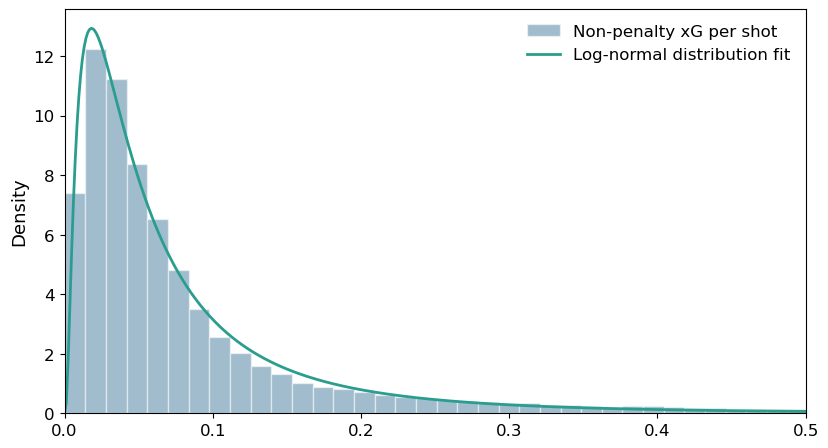

Log-normal parameters (xG <= 0.6): exp(mu) = 0.0509, sigma = 1.0137


In [42]:
phases_df = pd.read_csv("data/phases.csv")

nonpen_shots = shots[(shots["penalty"] == 0) & (shots["xg"] > 0) & 
                     (shots["xg"] <= 0.6)]["xg"].astype(float)

fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.hist(nonpen_shots, bins=43, density=True, alpha=0.5, color="#457b9d",
        edgecolor="white", label="Non-penalty xG per shot")

lognorm_fit = stats.lognorm.fit(nonpen_shots, floc=0)
x = np.linspace(0, 0.6, 500)
lognorm_pdf = stats.lognorm.pdf(x, *lognorm_fit)
ax.plot(x, lognorm_pdf, color="#2a9d8f", linewidth=2, label="Log-normal distribution fit")

ax.set_xlim(0, 0.5)
ax.set_ylabel("Density")
ax.legend(frameon=False)
fig.tight_layout(pad=0.4)
shot_quality_fig = fig
plt.show()

sigma, _, exp_mu = lognorm_fit
print(f"Log-normal parameters (xG <= 0.6): exp(mu) = {exp_mu:.4f}, sigma = {sigma:.4f}")

In [17]:
all_teams = sorted(pd.concat([phases_df["team1"], phases_df["team2"]]).unique())
team_to_id = {team: i + 1 for i, team in enumerate(all_teams)}
n_teams = len(all_teams)

def get_margin_id(diff):
    if diff <= -2: return 1
    if diff == -1: return 2
    if diff == 0: return 3
    if diff == 1: return 4
    return 5

phases_df = phases_df.sort_values(["match_id", "half", "phase_start_minute"])
phases_df["phase_end_minute"] = phases_df.groupby(["match_id", "half"])["phase_start_minute"].shift(-1)
phases_df["phase_end_minute"] = phases_df["phase_end_minute"].fillna(100)

def count_shots_in_phase(p_row, s_df):
    mask = (
        (s_df["match_id"] == p_row["match_id"])
        & (s_df["half"] == p_row["half"])
        & (s_df["minute"] >= p_row["phase_start_minute"])
        & (s_df["minute"] < p_row["phase_end_minute"])
        & (s_df["penalty"] == 0)
    )
    relevant_shots = s_df[mask]
    t1_shots = relevant_shots[relevant_shots["team"] == 1]
    t2_shots = relevant_shots[relevant_shots["team"] == 2]
    return len(t1_shots), len(t2_shots)

counts = phases_df.apply(lambda x: count_shots_in_phase(x, shots), axis=1)
phases_df["count1"], phases_df["count2"] = zip(*counts)

phase_data = []
for _, row in phases_df.iterrows():
    phase_data.append({
        "team_id": team_to_id[row["team1"]],
        "opp_id": team_to_id[row["team2"]],
        "duration": row["duration"],
        "shot_count": row["count1"],
        "margin_id": get_margin_id(row["score1"] - row["score2"])
    })
    phase_data.append({
        "team_id": team_to_id[row["team2"]],
        "opp_id": team_to_id[row["team1"]],
        "duration": row["duration"],
        "shot_count": row["count2"],
        "margin_id": get_margin_id(row["score2"] - row["score1"])
    })
df_p = pd.DataFrame(phase_data)

shot_data = []
for _, row in shots.iterrows():
    if row["penalty"] == 1 or row["xg"] <= 0:
        continue
    attacker = row["team1"] if row["team"] == 1 else row["team2"]
    margin = row["score1"] - row["score2"] if row["team"] == 1 else row["score2"] - row["score1"]
    shot_data.append({
        "xg": row["xg"],
        "team_id": team_to_id[attacker],
        "margin_id": get_margin_id(margin)
    })
df_s = pd.DataFrame(shot_data)

stan_data = {
    "N_phases": len(df_p),
    "phase_duration": df_p["duration"].values,
    "shot_counts": df_p["shot_count"].values,
    "p_team": df_p["team_id"].values,
    "p_opp": df_p["opp_id"].values,
    "p_margin": df_p["margin_id"].values,
    "N_shots": len(df_s),
    "shot_xg": df_s["xg"].values,
    "s_team": df_s["team_id"].values,
    "s_margin": df_s["margin_id"].values,
    "n_teams": n_teams
}

In [ ]:
model = CmdStanModel(stan_file="model.stan")
fit = model.sample(data=stan_data, chains=4, iter_sampling=1000, iter_warmup=500, inits=0)

10:45:30 - cmdstanpy - INFO - compiling stan file /Users/vik.shirvaikar/Desktop/vshirvaikar.github.io/blog/2026.06 Expected Shots/model.stan to exe file /Users/vik.shirvaikar/Desktop/vshirvaikar.github.io/blog/2026.06 Expected Shots/model
10:45:38 - cmdstanpy - INFO - compiled model executable: /Users/vik.shirvaikar/Desktop/vshirvaikar.github.io/blog/2026.06 Expected Shots/model
10:45:38 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

10:48:33 - cmdstanpy - INFO - CmdStan done processing.


In [ ]:
results_dir = Path("results")
results_dir.mkdir(parents=True, exist_ok=True)

fit.save_csvfiles(dir=str(results_dir))
summary = fit.summary()
summary.to_csv(results_dir / "fit_summary.csv")

rhat = summary["R_hat"].dropna()
n_eff = summary["N_Eff"].dropna()

print(f"Saved fit draws and summary")
print(f"Max R-hat: {rhat.max():.3f} (target < 1.01)")
print(f"Median R-hat: {rhat.median():.3f}")
print(f"Min N_eff: {n_eff.min():.0f} (higher is better)")
print(f"Params with R-hat > 1.01: {(rhat > 1.01).sum()}")
print(f"Params with N_eff < 400: {(n_eff < 400).sum()}")

Saved fit draws and summary
Max R-hat: 1.008 (target < 1.01)
Median R-hat: 1.000
Min N_eff: 1145 (higher is better)
Params with R-hat > 1.01: 0
Params with N_eff < 400: 0


         Margin  Quantity_Mult  Quality_Mult  Total_Mult
0   -2 or worse       1.131872      1.012595    1.146121
1            -1       1.132540      1.011210    1.145235
2          Tied       1.000000      1.000000    1.000000
3            +1       1.124601      1.163234    1.308175
4  +2 or better       1.235345      1.234212    1.524673


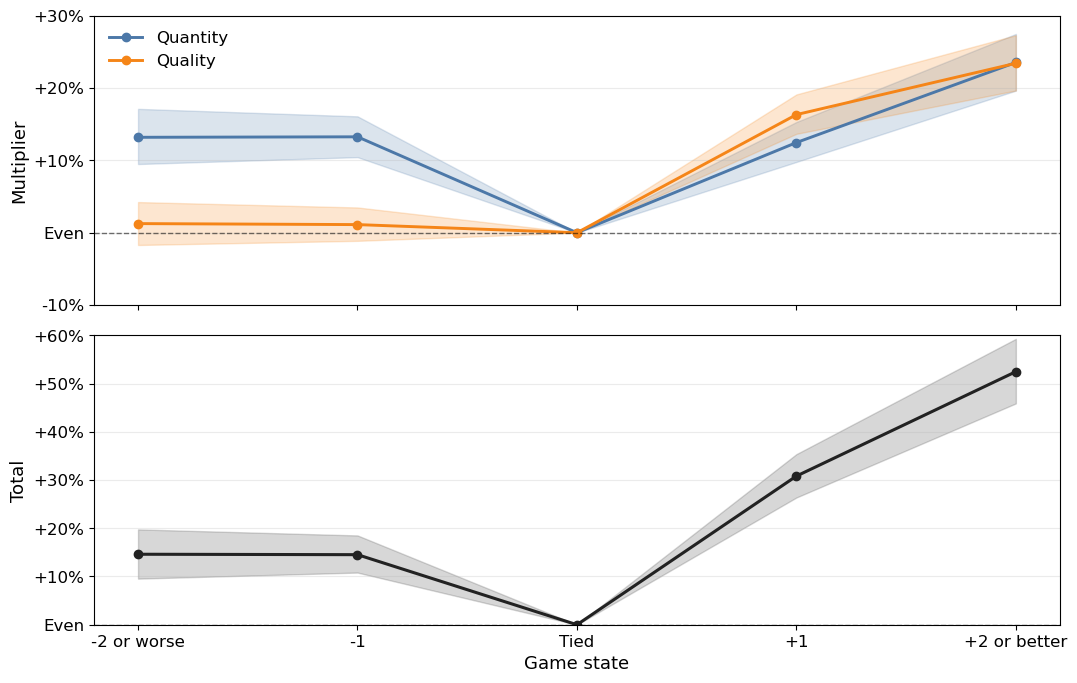

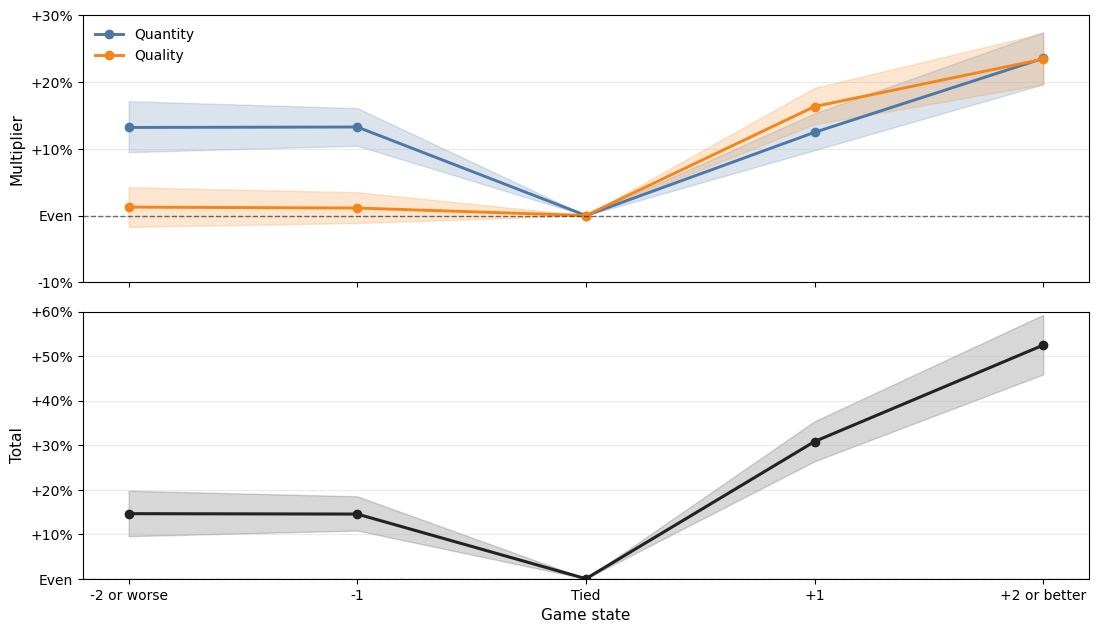

In [44]:
margins = ["-2 or worse", "-1", "Tied", "+1", "+2 or better"]
tied_idx = 2

quantity_draws = fit.stan_variable("vol_mult")
qual_draws = fit.stan_variable("qual_mult")
prod_draws = quantity_draws * qual_draws

def summarize(draws):
    mean = draws.mean(axis=0)
    lo, hi = np.percentile(draws, [5, 95], axis=0)
    return mean, lo, hi

def pct_label(v):
    if np.isclose(v, 1.0):
        return "Even"
    return f"{(v - 1.0) * 100:+.0f}%"

quantity_mean, quantity_lo, quantity_hi = summarize(quantity_draws)
qual_mean, qual_lo, qual_hi = summarize(qual_draws)
prod_mean, prod_lo, prod_hi = summarize(prod_draws)

quantity_mean[tied_idx], quantity_lo[tied_idx], quantity_hi[tied_idx] = 1.0, 1.0, 1.0
qual_mean[tied_idx], qual_lo[tied_idx], qual_hi[tied_idx] = 1.0, 1.0, 1.0
prod_mean[tied_idx], prod_lo[tied_idx], prod_hi[tied_idx] = 1.0, 1.0, 1.0

coef_df = pd.DataFrame({"Margin": margins, "Quantity_Mult": quantity_mean, 
    "Quality_Mult": qual_mean, "Total_Mult": prod_mean})
print(coef_df)

def draw_tactical(ax1, ax2):
    x = np.arange(len(margins))
    ax1.fill_between(x, quantity_lo, quantity_hi, color="#4c78a8", alpha=0.20)
    ax1.plot(x, quantity_mean, color="#4c78a8", marker="o", linewidth=2.1, label="Quantity")
    ax1.fill_between(x, qual_lo, qual_hi, color="#f58518", alpha=0.20)
    ax1.plot(x, qual_mean, color="#f58518", marker="o", linewidth=2.1, label="Quality")
    ax1.axhline(1.0, color="black", linewidth=1, linestyle="--", alpha=0.55)
    ax1.set_ylim(0.9, 1.3)
    top_ticks = np.arange(0.9, 1.31, 0.1)
    ax1.set_yticks(top_ticks)
    ax1.set_yticklabels([pct_label(v) for v in top_ticks])
    ax1.set_ylabel("Multiplier")
    ax1.legend(frameon=False, loc="upper left")
    ax1.grid(axis="y", alpha=0.25)

    ax2.fill_between(x, prod_lo, prod_hi, color="#222222", alpha=0.18)
    ax2.plot(x, prod_mean, color="#222222", marker="o", linewidth=2.2, label="Total")
    ax2.axhline(1.0, color="black", linewidth=1, linestyle="--", alpha=0.55)
    ax2.set_ylim(1.0, 1.6)
    bottom_ticks = np.arange(1.0, 1.61, 0.1)
    ax2.set_yticks(bottom_ticks)
    ax2.set_yticklabels([pct_label(v) for v in bottom_ticks])
    ax2.set_ylabel("Total")
    ax2.set_xlabel("Game state")
    ax2.set_xticks(x)
    ax2.set_xticklabels(margins)
    ax2.grid(axis="y", alpha=0.25)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10.8, 6.8), sharex=True, 
                               gridspec_kw={"height_ratios": [1, 1]})
draw_tactical(ax1, ax2)
fig.tight_layout(pad=0.6, h_pad=1.1)
tactical_coeff_fig = fig
plt.show()

thumb_fig, (ax1_t, ax2_t) = plt.subplots(2, 1, figsize=(11, 6.3), sharex=True, 
                                         gridspec_kw={"height_ratios": [1, 1]})
draw_tactical(ax1_t, ax2_t)
for ax_t in (ax1_t, ax2_t):
    ax_t.tick_params(labelsize=10)
ax1_t.legend(frameon=False, loc="upper left", fontsize=10)
ax1_t.yaxis.label.set_size(11)
ax2_t.yaxis.label.set_size(11)
ax2_t.xaxis.label.set_size(11)
thumb_fig.tight_layout(pad=0.6, h_pad=1.1)
tactical_thumbnail_fig = thumb_fig
plt.show()

Top-left outlier (worst attack with positive defense): Bastia
Bottom-right outlier (best attack with negative defense): Sevilla


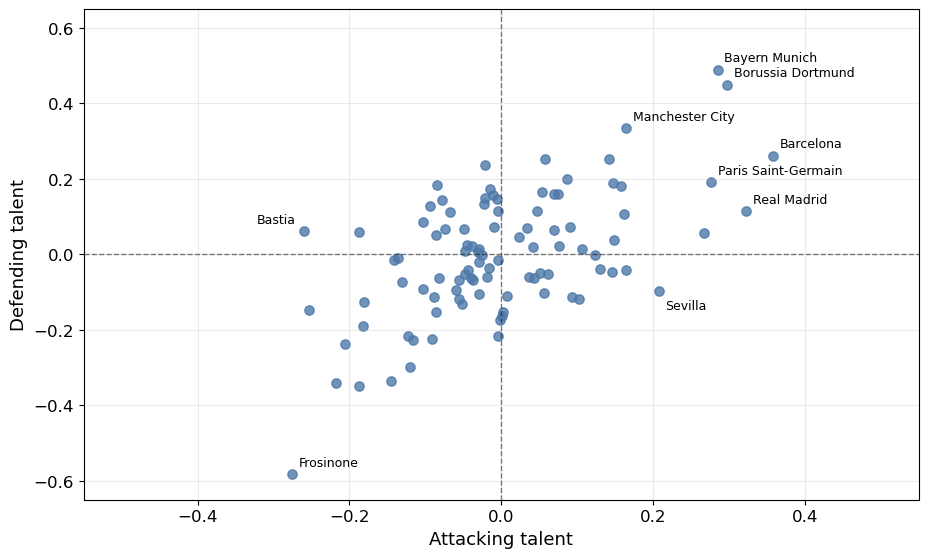

In [27]:
team_stats = []
for team_name, tid in team_to_id.items():
    attack = summary.loc[f"att_talent[{tid}]", "Mean"]
    defense = summary.loc[f"def_talent[{tid}]", "Mean"]
    team_stats.append({"Team": team_name, "Attack": attack, "Defense": defense, "Combined": attack + defense})
df_teams = pd.DataFrame(team_stats).sort_values("Combined", ascending=False).reset_index(drop=True)

top_6 = df_teams.head(6)
bottom_1 = df_teams.tail(1)

worst_attack_positive_def = df_teams[df_teams["Defense"] > 0].nsmallest(1, "Attack")
best_attack_negative_def = df_teams[df_teams["Defense"] < 0].nlargest(1, "Attack")

top_left_outlier_team = worst_attack_positive_def.iloc[0]["Team"]
bottom_right_outlier_team = best_attack_negative_def.iloc[0]["Team"]
print(f"Top-left outlier (worst attack with positive defense): {top_left_outlier_team}")
print(f"Bottom-right outlier (best attack with negative defense): {bottom_right_outlier_team}")

labeled_teams = pd.concat([top_6, bottom_1, worst_attack_positive_def, best_attack_negative_def], ignore_index=True)
labeled_teams = labeled_teams.drop_duplicates(subset=["Team"]).reset_index(drop=True)
bottom_left_labels = {"Chievo"}

fig, ax = plt.subplots(figsize=(9.2, 5.5))
ax.scatter(df_teams["Attack"], df_teams["Defense"], s=45, alpha=0.8, color="#4c78a8")

for _, row in labeled_teams.iterrows():
    team = row["Team"]
    if team == top_left_outlier_team:
        ax.annotate(team, (row["Attack"], row["Defense"]), xytext=(-6, 4), textcoords="offset points", ha="right", va="bottom", fontsize=9)
    elif team == bottom_right_outlier_team:
        ax.annotate(team, (row["Attack"], row["Defense"]), xytext=(5, -6), textcoords="offset points", ha="left", va="top", fontsize=9)
    elif team in bottom_left_labels:
        ax.annotate(team, (row["Attack"], row["Defense"]), xytext=(-6, -6), textcoords="offset points", ha="right", va="top", fontsize=9)
    else:
        ax.annotate(team, (row["Attack"], row["Defense"]), xytext=(5, 4), textcoords="offset points", ha="left", va="bottom", fontsize=9)

ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)
ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)
ax.set_xlim(-0.55, 0.55)
ax.set_ylim(-0.65, 0.65)
ax.set_xlabel("Attacking talent")
ax.set_ylabel("Defending talent")
ax.grid(alpha=0.25)
fig.tight_layout(pad=0.4)
team_scatter_fig = fig
plt.show()

In [45]:
# Thumbnail spec: render preview figure at 11 x 6.3 inches and export at dpi=100 for exact 1100 x 630 px.
quantity_path = blog_visuals / "shots-quantity-lognormal.png"
shot_quantity_fig.savefig(quantity_path, dpi=220)
print(f"Saved figure: {quantity_path.resolve()}")

quality_path = blog_visuals / "shots-quality-lognormal.png"
shot_quality_fig.savefig(quality_path, dpi=220)
print(f"Saved figure: {quality_path.resolve()}")

tactical_path = blog_visuals / "tactical-multipliers-ci.png"
tactical_coeff_fig.savefig(tactical_path, dpi=220)
print(f"Saved figure: {tactical_path.resolve()}")

teams_path = blog_visuals / "team-attack-defense-scatter.png"
team_scatter_fig.savefig(teams_path, dpi=220)
print(f"Saved figure: {teams_path.resolve()}")

thumbnail_path = blog_visuals / "thumbnail-expected-shots.png"
tactical_thumbnail_fig.savefig(thumbnail_path, dpi=100)
print(f"Saved thumbnail: {thumbnail_path.resolve()}")

print(f"![figure]({quality_path.as_posix()})")
print(f"![figure]({tactical_path.as_posix()})")
print(f"![figure]({teams_path.as_posix()})")
print(f"![Thumbnail]({thumbnail_path.as_posix()})")

Saved figure: /Users/vik.shirvaikar/Desktop/vshirvaikar.github.io/blog/2026.06 Expected Shots/visuals/shots-quantity-lognormal.png
Saved figure: /Users/vik.shirvaikar/Desktop/vshirvaikar.github.io/blog/2026.06 Expected Shots/visuals/shots-quality-lognormal.png
Saved figure: /Users/vik.shirvaikar/Desktop/vshirvaikar.github.io/blog/2026.06 Expected Shots/visuals/tactical-multipliers-ci.png
Saved figure: /Users/vik.shirvaikar/Desktop/vshirvaikar.github.io/blog/2026.06 Expected Shots/visuals/team-attack-defense-scatter.png
Saved thumbnail: /Users/vik.shirvaikar/Desktop/vshirvaikar.github.io/blog/2026.06 Expected Shots/visuals/thumbnail-expected-shots.png
![figure](visuals/shots-quality-lognormal.png)
![figure](visuals/tactical-multipliers-ci.png)
![figure](visuals/team-attack-defense-scatter.png)
![Thumbnail](visuals/thumbnail-expected-shots.png)
